# EDA — Exploratory Data Analysis
## RACE Dataset | NUCES AI Lab Project (Spring 2026)

This notebook covers all **5 EDA checks** required by the roadmap (worth **10 marks**).

> **Before running:** select the `venv` kernel in VS Code.  
> `Ctrl+Shift+P` → *Python: Select Interpreter* → choose `venv`.


In [1]:
# ===== CELL 1 — Imports + Path Detection + Data Loading =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

# ------------------------------------------------------------------
# Automatically find the project root (works from main project
# folder AND from inside the .claude/worktrees/ subfolder).
# ------------------------------------------------------------------
def find_project_root():
    current = Path.cwd()
    for _ in range(9):
        if (current / "data" / "raw" / "train.csv").exists():
            return current
        current = current.parent
    raise FileNotFoundError(
        "Cannot find data/raw/train.csv.\n"
        "Make sure train.csv, val.csv (or dev.csv), and test.csv "
        "are inside race_rc_project/data/raw/"
    )

PROJECT_ROOT = find_project_root()
DATA_RAW  = PROJECT_ROOT / "data" / "raw"
DATA_PROC = PROJECT_ROOT / "data" / "processed"
DATA_PROC.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Data folder  : {DATA_RAW}")

# ------------------------------------------------------------------
# Load datasets
# NOTE: The CSV has an unnamed first column (row numbers from pandas
# when it was saved). index_col=0 treats it as the DataFrame index.
# NOTE: RACE validation split is sometimes named val.csv, sometimes dev.csv.
# ------------------------------------------------------------------
train_df = pd.read_csv(DATA_RAW / "train.csv", index_col=0)

_val_path = DATA_RAW / "val.csv" if (DATA_RAW / "val.csv").exists() else DATA_RAW / "dev.csv"
val_df  = pd.read_csv(_val_path, index_col=0)
test_df = pd.read_csv(DATA_RAW / "test.csv", index_col=0)

print(f"\nValidation file used : {_val_path.name}")
print("\nAll three datasets loaded successfully!")


Project root : c:\Users\khawa\OneDrive\Desktop\race_rc_project
Data folder  : c:\Users\khawa\OneDrive\Desktop\race_rc_project\data\raw

Validation file used : dev.csv

All three datasets loaded successfully!


In [2]:
# ===== CELL 2 — Basic Dataset Inspection =====
print("=" * 55)
print("  DATASET SHAPES")
print("=" * 55)
print(f"  Train : {train_df.shape[0]:>8,} rows  x  {train_df.shape[1]} columns")
print(f"  Val   : {val_df.shape[0]:>8,} rows  x  {val_df.shape[1]} columns")
print(f"  Test  : {test_df.shape[0]:>8,} rows  x  {test_df.shape[1]} columns")

print("\n" + "=" * 55)
print("  COLUMN NAMES")
print("=" * 55)
print(train_df.columns.tolist())

print("\n" + "=" * 55)
print("  DATA TYPES")
print("=" * 55)
print(train_df.dtypes.to_string())

print("\n" + "=" * 55)
print("  FIRST 2 ROWS")
print("=" * 55)
train_df.head(2)


  DATASET SHAPES
  Train :   87,866 rows  x  8 columns
  Val   :   87,866 rows  x  8 columns
  Test  :   87,866 rows  x  8 columns

  COLUMN NAMES
['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']

  DATA TYPES
id          object
article     object
question    object
A           object
B           object
C           object
D           object
answer      object

  FIRST 2 ROWS


,id,article,question,A,B,C,D,answer
0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B


In [3]:
# ===== CELL 3 — Missing Values Check =====
print("=" * 55)
print("  MISSING VALUES  (training set)")
print("=" * 55)
missing = train_df.isnull().sum()
if missing.sum() == 0:
    print("  No NaN values found — dataset is clean!")
else:
    print(missing[missing > 0].to_string())

# Also flag blank / whitespace-only strings
CRITICAL = ["article", "question", "A", "B", "C", "D", "answer"]
blank = {c: (train_df[c].astype(str).str.strip() == "").sum() for c in CRITICAL}
blank_total = sum(blank.values())
print()
if blank_total == 0:
    print("  No blank strings in critical columns either.")
else:
    print("  Blank strings found:")
    for col, n in blank.items():
        if n > 0:
            print(f"    {col}: {n}")
print("\nConclusion: safe to proceed to preprocessing.")


  MISSING VALUES  (training set)
A    4
C    1
D    9

  No blank strings in critical columns either.

Conclusion: safe to proceed to preprocessing.


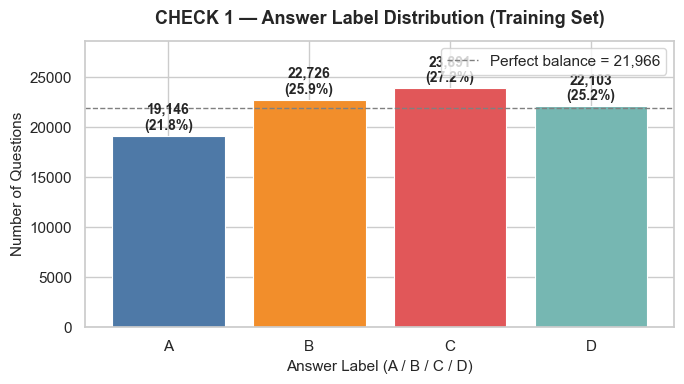

Answer counts:
  A: 19,146  (21.79%)
  B: 22,726  (25.86%)
  C: 23,891  (27.19%)
  D: 22,103  (25.16%)

Coefficient of variation: 0.0920  =>  Slightly imbalanced — use class_weight='balanced'


In [4]:
# ===== CELL 4 — CHECK 1: Answer Label Distribution =====
answer_counts = train_df["answer"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2"]
bars = ax.bar(answer_counts.index, answer_counts.values,
              color=colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, answer_counts.values):
    pct = val / len(train_df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

perfect_balance = len(train_df) / 4
ax.axhline(perfect_balance, color="gray", linestyle="--", linewidth=1,
           label=f"Perfect balance = {perfect_balance:,.0f}")
ax.set_title("CHECK 1 — Answer Label Distribution (Training Set)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Answer Label (A / B / C / D)", fontsize=11)
ax.set_ylabel("Number of Questions", fontsize=11)
ax.set_ylim(0, answer_counts.max() * 1.20)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC / "plot_01_answer_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Answer counts:")
for label, cnt in answer_counts.items():
    print(f"  {label}: {cnt:,}  ({cnt/len(train_df)*100:.2f}%)")

cv = answer_counts.std() / answer_counts.mean()
balance_msg = "Well balanced" if cv < 0.05 else "Slightly imbalanced — use class_weight='balanced'"
print(f"\nCoefficient of variation: {cv:.4f}  =>  {balance_msg}")


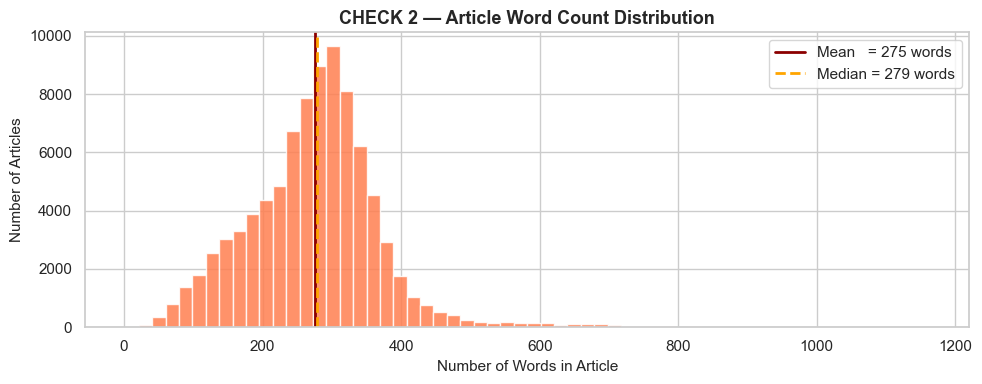

Article Length Statistics:
Count      87866.0
Mean         275.0
Std Dev       97.9
Min            2.0
Q1           217.0
Median       279.0
Q3           326.0
Max         1162.0

Tip: Mean ~275 words per article.
     Use max_features=10000 in CountVectorizer to keep memory manageable.


In [5]:
# ===== CELL 5 — CHECK 2: Article Word Count Distribution =====
train_df["article_length"] = train_df["article"].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df["article_length"], bins=60, color="coral", edgecolor="white", alpha=0.85)
mean_val   = train_df["article_length"].mean()
median_val = train_df["article_length"].median()
ax.axvline(mean_val,   color="darkred", linewidth=2.0,
           label=f"Mean   = {mean_val:.0f} words")
ax.axvline(median_val, color="orange",  linewidth=2.0, linestyle="--",
           label=f"Median = {median_val:.0f} words")
ax.set_title("CHECK 2 — Article Word Count Distribution",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Words in Article", fontsize=11)
ax.set_ylabel("Number of Articles", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC / "plot_02_article_length.png", dpi=150, bbox_inches="tight")
plt.show()

print("Article Length Statistics:")
print(train_df["article_length"].describe().round(1).rename({
    "count": "Count", "mean": "Mean", "std": "Std Dev",
    "min": "Min", "25%": "Q1", "50%": "Median", "75%": "Q3", "max": "Max",
}).to_string())
print(f"\nTip: Mean ~{mean_val:.0f} words per article.")
print("     Use max_features=10000 in CountVectorizer to keep memory manageable.")


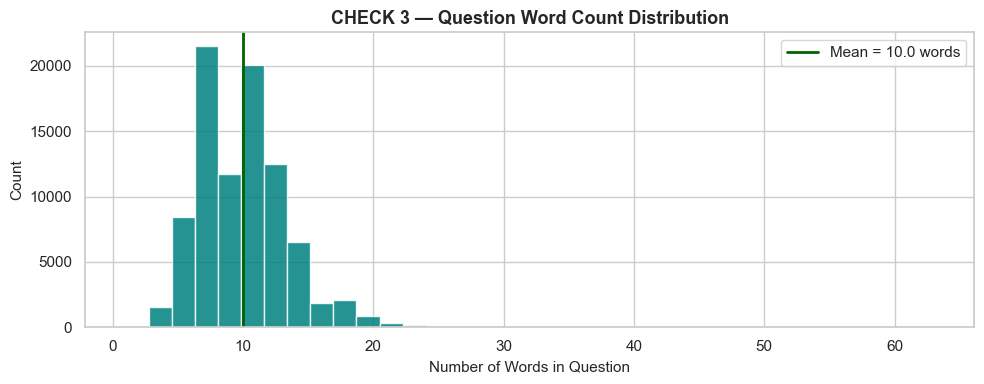

Question Length Statistics:
count    87866.0
mean        10.0
std          3.4
min          1.0
25%          8.0
50%         10.0
75%         12.0
max         63.0


In [6]:
# ===== CELL 6 — CHECK 3: Question Word Count Distribution =====
train_df["q_length"] = train_df["question"].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df["q_length"], bins=35, color="teal", edgecolor="white", alpha=0.85)
q_mean = train_df["q_length"].mean()
ax.axvline(q_mean, color="darkgreen", linewidth=2,
           label=f"Mean = {q_mean:.1f} words")
ax.set_title("CHECK 3 — Question Word Count Distribution",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Words in Question", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC / "plot_03_question_length.png", dpi=150, bbox_inches="tight")
plt.show()

print("Question Length Statistics:")
print(train_df["q_length"].describe().round(1).to_string())


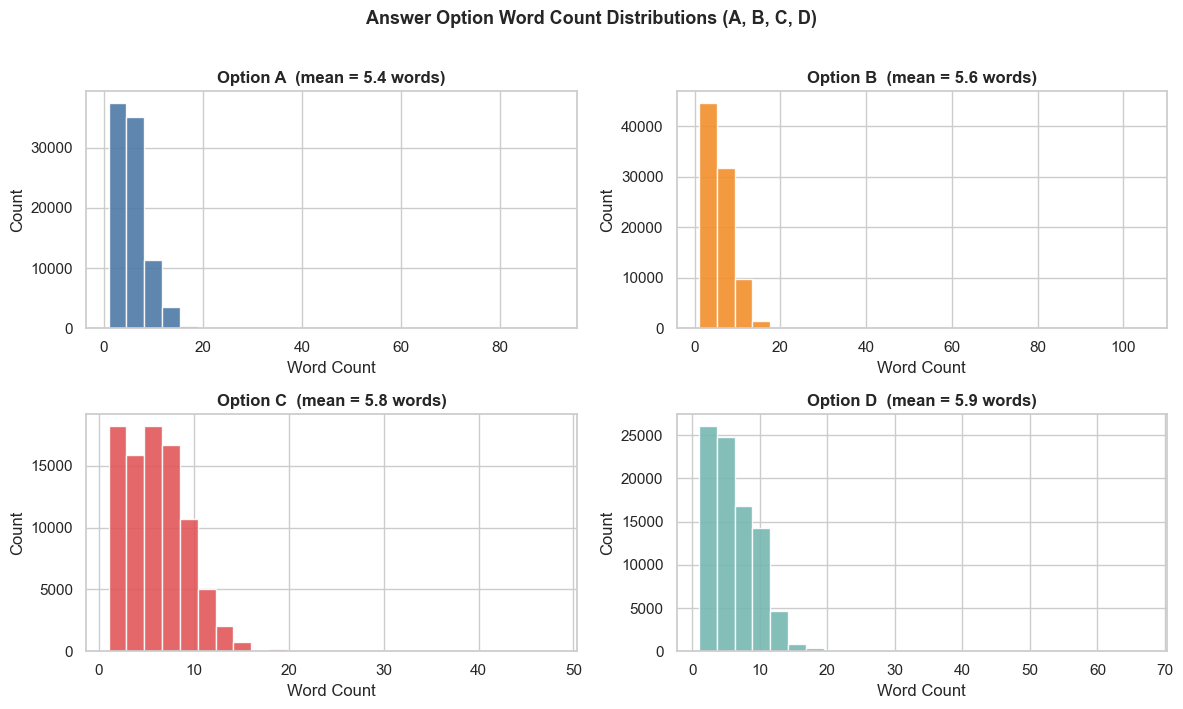

Options A, B, C, D have similar length distributions — good sign of quality dataset.


In [7]:
# ===== CELL 7 — BONUS: Answer Option Word Count Distributions =====
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()
palette = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2"]

for i, opt in enumerate(["A", "B", "C", "D"]):
    lengths = train_df[opt].apply(lambda x: len(str(x).split()))
    axes[i].hist(lengths, bins=25, color=palette[i], edgecolor="white", alpha=0.9)
    axes[i].set_title(f"Option {opt}  (mean = {lengths.mean():.1f} words)",
                      fontweight="bold")
    axes[i].set_xlabel("Word Count")
    axes[i].set_ylabel("Count")

fig.suptitle("Answer Option Word Count Distributions (A, B, C, D)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DATA_PROC / "plot_04_option_lengths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Options A, B, C, D have similar length distributions — good sign of quality dataset.")


In [8]:
# ===== CELL 8 — Text Cleaning Function (Preview) =====
def clean_text(text):
    # Step 1: lowercase everything
    text = str(text).lower()
    # Step 2: remove everything except letters, digits, spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    # Step 3: collapse multiple spaces into one
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Show what cleaning does on a real example
sample = train_df.iloc[0]
print("=" * 60)
print("TEXT CLEANING DEMO")
print("=" * 60)
print("\nRAW article (first 250 chars):")
print(sample["article"][:250])
print("\nCLEANED article (first 250 chars):")
print(clean_text(sample["article"])[:250])
print("\nRAW question    :", sample["question"])
print("CLEANED question:", clean_text(sample["question"]))


TEXT CLEANING DEMO

RAW article (first 250 chars):
In the summer between my first year and second year in college, I was invited to be an instructor  at a high school camp. On the first day, when we were dancing and playing games, I noticed a boy under the tree who was small and thin. His shyness mad

CLEANED article (first 250 chars):
in the summer between my first year and second year in college i was invited to be an instructor at a high school camp on the first day when we were dancing and playing games i noticed a boy under the tree who was small and thin his shyness made him 

RAW question    : Before the writer came to the high school summer camp,he was a (n)   _  .
CLEANED question: before the writer came to the high school summer camp he was a n


Building word cloud from 5,000 articles...
(This may take ~20 seconds — please wait)


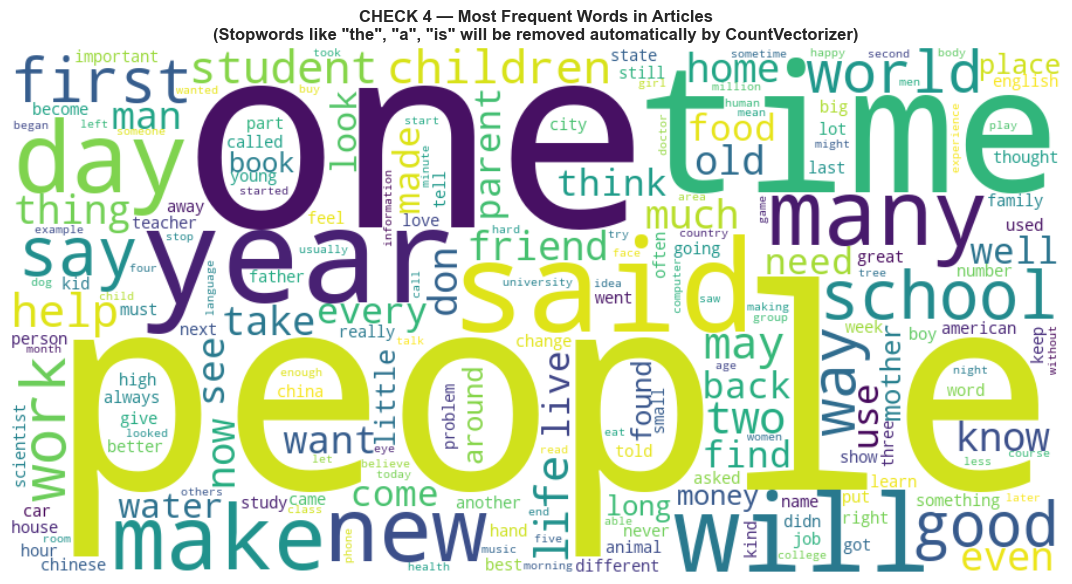

Saved to data/processed/plot_05_wordcloud.png


In [9]:
# ===== CELL 9 — CHECK 4: Word Cloud =====
try:
    from wordcloud import WordCloud

    SAMPLE_SIZE = min(5000, len(train_df))
    print(f"Building word cloud from {SAMPLE_SIZE:,} articles...")
    print("(This may take ~20 seconds — please wait)")

    sample_text = " ".join(
        train_df["article"].sample(SAMPLE_SIZE, random_state=42).apply(clean_text)
    )

    wc = WordCloud(
        width=900,
        height=450,
        background_color="white",
        colormap="viridis",
        max_words=200,
        collocations=False,
        min_word_length=3,
    ).generate(sample_text)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(
        "CHECK 4 — Most Frequent Words in Articles\n"
        '(Stopwords like "the", "a", "is" will be removed automatically by CountVectorizer)',
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(DATA_PROC / "plot_05_wordcloud.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to data/processed/plot_05_wordcloud.png")

except ImportError:
    print("wordcloud is not installed.")
    print("Fix: make sure your venv is active, then run:  pip install wordcloud")


In [10]:
# ===== CELL 10 — CHECK 5: Sample Data Review =====
def print_sample(df, idx, label=""):
    row = df.iloc[idx]
    print("=" * 60)
    print(f"  CHECK 5 — FULL SAMPLE ({label}  index={idx})")
    print("=" * 60)
    print(f"  ID       : {row.get('id', 'N/A')}")
    print(f"\n  ARTICLE (first 500 chars):")
    print("  " + str(row["article"])[:500] + "...")
    print(f"\n  QUESTION : {row['question']}")
    print("\n  OPTIONS  :")
    for opt in ["A", "B", "C", "D"]:
        marker = "  <-- CORRECT" if row["answer"] == opt else ""
        print(f"    {opt}: {row[opt]}{marker}")
    print(f"\n  CORRECT ANSWER: {row['answer']}")
    print()

print_sample(train_df, 0,   label="entry #0")
print_sample(train_df, 100, label="entry #100")


  CHECK 5 — FULL SAMPLE (entry #0  index=0)
  ID       : middle7348.txt

  ARTICLE (first 500 chars):
  In the summer between my first year and second year in college, I was invited to be an instructor  at a high school camp. On the first day, when we were dancing and playing games, I noticed a boy under the tree who was small and thin. His shyness made him appear weak. I walked towards him, introduced myself and invited him to join in the activities and meet some new people. He quietly replied, "No, I really don't want to do this." I could understand that he was in a new world but I knew it would...

  QUESTION : Before the writer came to the high school summer camp,he was a (n)   _  .

  OPTIONS  :
    A: instructor
    B: camper
    C: student  <-- CORRECT
    D: reporter

  CORRECT ANSWER: C

  CHECK 5 — FULL SAMPLE (entry #100  index=100)
  ID       : middle5428.txt

  ARTICLE (first 500 chars):
  Are you taking good care of your hair and using the right products? Could your shamp

In [11]:
# ===== CELL 11 — Summary Statistics Table (put this in your report!) =====

# Make sure length columns exist
if "article_length" not in train_df.columns:
    train_df["article_length"] = train_df["article"].apply(lambda x: len(str(x).split()))
if "q_length" not in train_df.columns:
    train_df["q_length"] = train_df["question"].apply(lambda x: len(str(x).split()))

ac = train_df["answer"].value_counts().sort_index()

rows = [
    ("Total training samples",            f"{len(train_df):,}"),
    ("Total validation samples",          f"{len(val_df):,}"),
    ("Total test samples",                f"{len(test_df):,}"),
    ("Average article word count",        f"{train_df['article_length'].mean():.1f}"),
    ("Median article word count",         f"{train_df['article_length'].median():.0f}"),
    ("Max article word count",            f"{train_df['article_length'].max()}"),
    ("Average question word count",       f"{train_df['q_length'].mean():.1f}"),
    ("Answer A — count (%)",              f"{ac.get('A',0):,}  ({ac.get('A',0)/len(train_df)*100:.1f}%)"),
    ("Answer B — count (%)",              f"{ac.get('B',0):,}  ({ac.get('B',0)/len(train_df)*100:.1f}%)"),
    ("Answer C — count (%)",              f"{ac.get('C',0):,}  ({ac.get('C',0)/len(train_df)*100:.1f}%)"),
    ("Answer D — count (%)",              f"{ac.get('D',0):,}  ({ac.get('D',0)/len(train_df)*100:.1f}%)"),
    ("Class balance (CV = std/mean)",     f"{ac.std()/ac.mean():.4f}  (< 0.05 = well balanced)"),
]

summary_df = pd.DataFrame(rows, columns=["Metric", "Value"])
print("\n=== SUMMARY STATISTICS TABLE ===\n")
print(summary_df.to_string(index=False))
print("\n(Copy this table into Section 4 of your final report!)")
summary_df



=== SUMMARY STATISTICS TABLE ===

                       Metric                            Value
       Total training samples                           87,866
     Total validation samples                           87,866
           Total test samples                           87,866
   Average article word count                            275.0
    Median article word count                              279
       Max article word count                             1162
  Average question word count                             10.0
         Answer A — count (%)                  19,146  (21.8%)
         Answer B — count (%)                  22,726  (25.9%)
         Answer C — count (%)                  23,891  (27.2%)
         Answer D — count (%)                  22,103  (25.2%)
Class balance (CV = std/mean) 0.0920  (< 0.05 = well balanced)

(Copy this table into Section 4 of your final report!)


,Metric,Value
0,Total training samples,"87,866"
1,Total validation samples,"87,866"
2,Total test samples,"87,866"
3,Average article word count,275.0
4,Median article word count,279
5,Max article word count,1162
6,Average question word count,10.0
7,Answer A — count (%),"19,146 (21.8%)"
8,Answer B — count (%),"22,726 (25.9%)"
9,Answer C — count (%),"23,891 (27.2%)"


## EDA Complete — Key Findings

| Finding | Implication for Modelling |
|---------|---------------------------|
| ~87,866 training rows | Large enough for robust classical ML |
| Answer labels ~25% each | Well balanced; add `class_weight='balanced'` as a safety net |
| Avg article ~250 words | High-dimensional OHE — set `max_features=10000` |
| Avg question ~10 words | Combine with article for the `combined` feature |
| Dominant words are stopwords | Use `stop_words='english'` in `CountVectorizer` |

## Next Steps

1. **Run preprocessing** — in your terminal (with venv active):
   ```
   python src/preprocessing.py
   ```
   This cleans the data and saves files to `data/processed/`.

2. **Next file to build**: `src/model_a_train.py` — train LR, SVM, Naive Bayes.
